In [7]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# acceder a un archivo en drive de google
# imagen = Image.open('/content/drive/MyDrive/Geoinformatica/imagenes/imagen1.jpg')

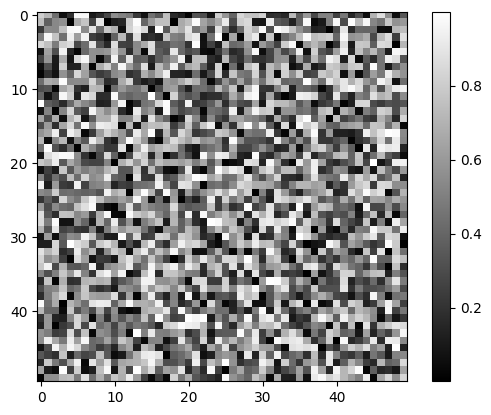

In [2]:
imagen =np.random.rand(50, 50)
plt.imshow(imagen, cmap='gray')
plt.colorbar()
plt.show()

In [ ]:
# muestra la matriz de valores de la imagen
print(np.asarray(imagen))

[[0.78893837 0.61487823 0.80618232 ... 0.13139015 0.59213197 0.37853575]
 [0.37872274 0.88515874 0.50172576 ... 0.35931874 0.22799628 0.70348285]
 [0.1992735  0.87101564 0.06725498 ... 0.66381205 0.55750175 0.3567783 ]
 ...
 [0.05726068 0.57363255 0.45178076 ... 0.66910561 0.86212769 0.66279973]
 [0.20721196 0.94231962 0.6058361  ... 0.35360179 0.56197196 0.34365307]
 [0.57445468 0.83437115 0.89253108 ... 0.85446822 0.36372176 0.17103056]]


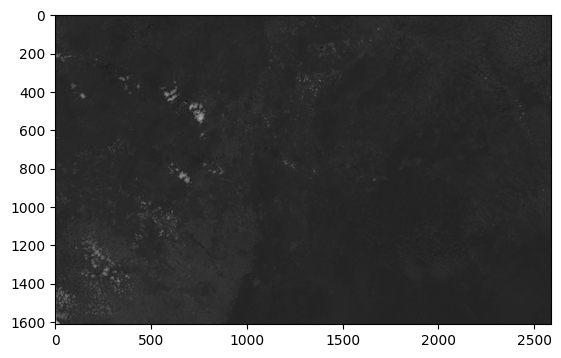

In [ ]:
# acceso a una imagen de 1 capa
imagen = Image.open('data/LC09_L2SP_008057_20230203_20230311_02_T1_SR_B1.TIF')
plt.imshow(imagen, cmap='gray')
#plt.axis('off')  # Oculta los ejes
plt.show()

In [7]:
matriz_imagen = np.asarray(imagen)
print(matriz_imagen)

[[ 8416  8856  8493 ...  7290  7651  8430]
 [ 8190  8435  8074 ...  7144  7364  8033]
 [ 8285  8332  7717 ...  8382  7623  7297]
 ...
 [46597 47257 46424 ...  7294  7231  7113]
 [44956 46416 47304 ...  7405  7277  7126]
 [44359 45252 46896 ...  7408  7227  7126]]


In [8]:
print(matriz_imagen.shape)

(1612, 2588)


In [8]:
# acceso a una imagen de 1 capa
imagen = Image.open('browser_images/2026-03-08-00:00_2026-03-08-23:59_Sentinel-2_L2A_True_color.tiff')
plt.imshow(imagen, cmap='gray')
#plt.axis('off')  # Oculta los ejes
plt.show()

UnidentifiedImageError: cannot identify image file 'browser_images/2026-03-08-00:00_2026-03-08-23:59_Sentinel-2_L2A_True_color.tiff'

In [5]:
matriz_imagen = np.asarray(imagen)
print(matriz_imagen)

[[-4.81897907e-04 -5.31977041e+18  1.26110920e-37 ...  6.88813434e-30
  -4.43277018e+24 -5.94358199e-22]
 [ 2.46548887e-15  2.63000280e+07  3.61899596e+12 ...  6.20861418e-10
  -1.30116126e-21  1.68213942e-34]
 [ 3.66876189e+18  2.01789827e+24  2.76869362e+29 ... -5.12046111e-23
  -5.72758337e-24  7.96828712e-15]
 ...
 [ 1.19903438e-18  1.06213096e+04  6.67199327e+26 ... -2.82495413e-23
   9.18714844e-12 -5.94358199e-22]
 [ 1.11938245e+03 -9.70639827e+35 -2.11945429e+15 ... -3.78106982e-01
   1.22508999e+33  1.05274893e+33]
 [ 2.44717446e-21 -2.86453421e-31 -3.28156951e-08 ... -1.11122586e-01
  -8.81953828e-24 -3.11723620e-01]]


/home/patricioaraneda/Documentos/github/Geoinformatica/.venv/lib/python3.13/site-packages/matplotlib/colors.py:2294: RuntimeWarning: overflow encountered in subtract
  resdat -= vmin
/home/patricioaraneda/Documentos/github/Geoinformatica/.venv/lib/python3.13/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


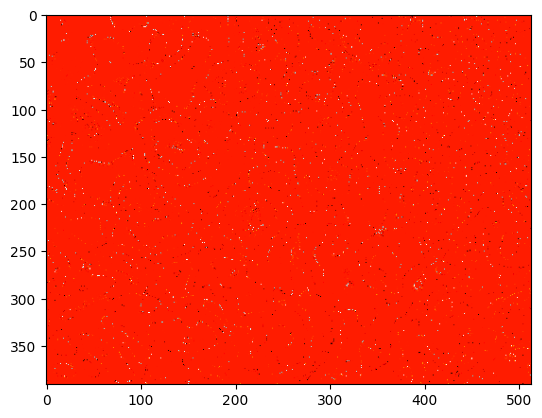

In [6]:
plt.imshow(matriz_imagen, cmap='hot')
plt.show()

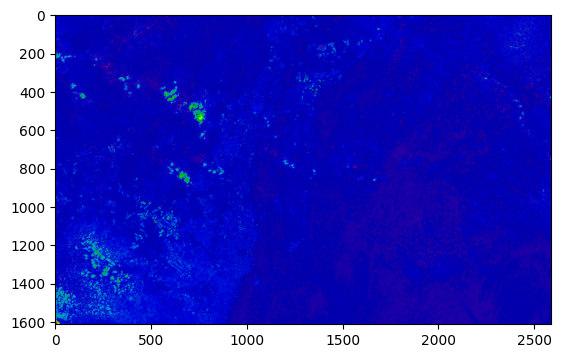

In [14]:
plt.imshow(matriz_imagen, cmap='nipy_spectral')
plt.show()

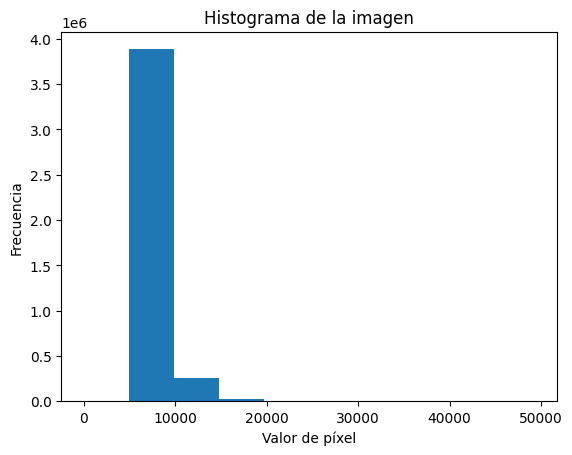

In [17]:
plt.hist(matriz_imagen.ravel())
plt.title('Histograma de la imagen')
plt.xlabel('Valor de píxel')
plt.ylabel('Frecuencia')
plt.show()

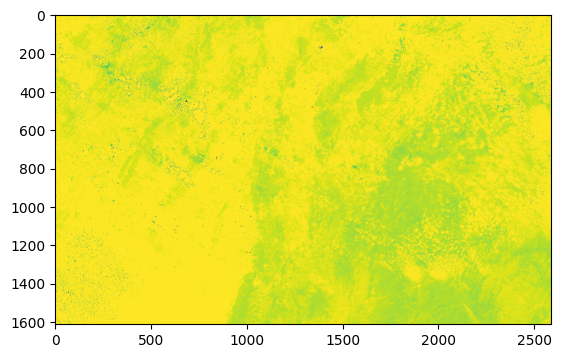

In [19]:
plt.imshow(matriz_imagen, clim=(0, 8000))
plt.show()

# Raster imagen satelital

In [ ]:
from pathlib import Path

# Buscar imágenes de la carpeta browser_images que correspondan a la banda B01
ruta = sorted(Path("browser_images").glob("*L2A_B*.tiff"))

# Cargar cada imagen como matriz numpy y normalizar cada array
lista_bandas = [np.asarray(Image.open(r)) / 255.0 for r in ruta]

# Crear el array 'banda' (apila si todas tienen misma forma, si no usa object)
try:
    banda = np.stack(lista_bandas)
except ValueError:
    banda = np.array(lista_bandas, dtype=object)

print(f"Imágenes (bandas) encontradas: {len(ruta)}")
print(f"Forma de bandas: {banda.shape}")

Imágenes (bandas) encontradas: 12
Forma de bandas: (12, 391, 513)


/tmp/ipykernel_188523/689421471.py:7: RuntimeWarning: invalid value encountered in divide
  lista_bandas = [np.asarray(Image.open(r)) / 255.0 for r in ruta]


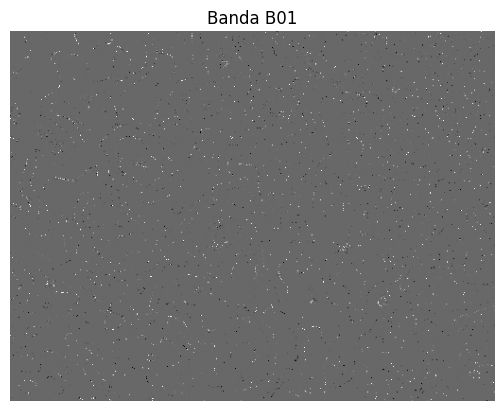

In [11]:
mostrar = banda[0]  # Mostrar la primera banda
plt.imshow(mostrar, cmap='gray')
plt.title('Banda B01')
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8.443945e+35..1.22359515e+36].


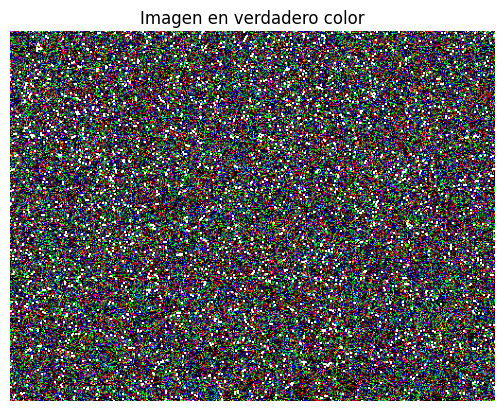

In [ ]:
verdadero_color = np.dstack((banda[3], banda[2], banda[1]))  # B04, B03, B02
plt.imshow(verdadero_color)
plt.title('Imagen en verdadero color')
plt.axis('off')
plt.show()

In [15]:
print(banda[0])

[[-1.8897957e-06 -2.0861844e+16  4.9455326e-40 ...  2.7012290e-32
  -1.7383413e+22 -2.3308166e-24]
 [ 9.6685841e-18  1.0313737e+05  1.4192141e+10 ...  2.4347508e-12
  -5.1025933e-24  6.5966253e-37]
 [ 1.4387302e+16  7.9133267e+21  1.0857622e+27 ... -2.0080240e-25
  -2.2461112e-26  3.1248184e-17]
 ...
 [ 4.7020957e-21  4.1652195e+01  2.6164680e+24 ... -1.1078251e-25
   3.6028031e-14 -2.3308166e-24]
 [ 4.3897352e+00 -3.8064307e+33 -8.3115854e+12 ... -1.4827725e-03
   4.8042745e+30  4.1284273e+30]
 [ 9.5967627e-24 -1.1233468e-33 -1.2868900e-10 ... -4.3577485e-04
  -3.4586426e-26 -1.2224455e-03]]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8.443945e+35..1.22359515e+36].


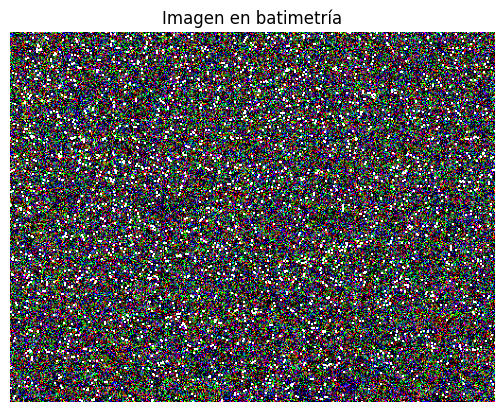

In [14]:
batimetria = np.dstack((banda[3], banda[2], banda[0]))  # B04, B03, B01
plt.imshow(batimetria)
plt.title('Imagen en batimetría')
plt.axis('off')
plt.show()